In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from transaction_analysis.config.paths import PLOTS_DIR
from transaction_analysis.data.loader import load_all_transactions, load_mcc_codes
from transaction_analysis.eda.pca import build_client_fraud_profile
from transaction_analysis.eda.step.analysis import TransactionAnalysis
from transaction_analysis.eda.visualizations import (
    plot_fraud_frequent_age,
    plot_fraudster_channel_mix,
    plot_fraudster_profile,
    plot_mcc_fraud_rate,
    plot_merchant_fraud_rate,
    plot_merchant_fraud_rate_volume,
    plot_state_fraud_rate,
    plot_top_states_by_amount,
)

analysis = TransactionAnalysis(load_all_transactions(), output_dir=PLOTS_DIR)

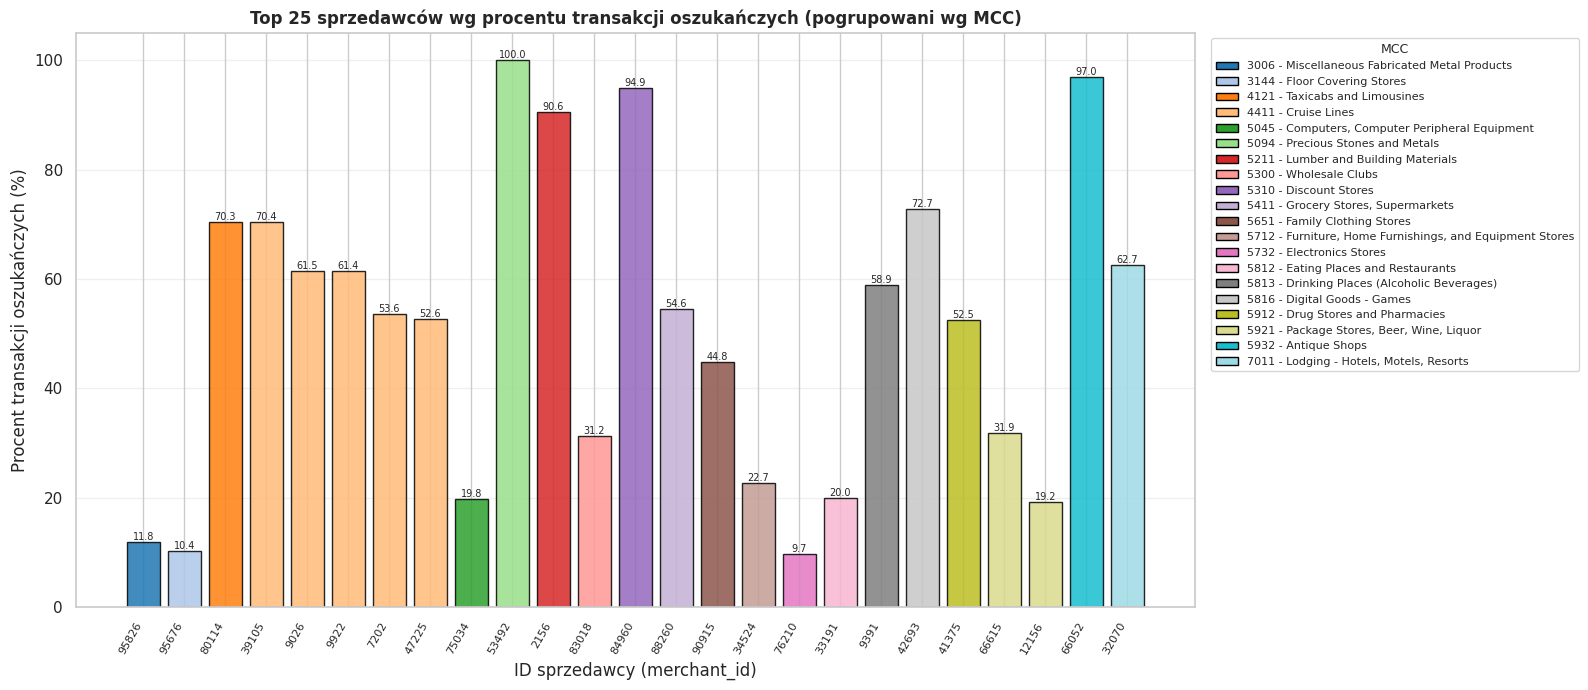

In [10]:
analysis.plot_graph(
    plot_merchant_fraud_rate,
    load_all_transactions(),
    mcc_codes=load_mcc_codes(),
    top_n=25,
    min_transactions=50,
)

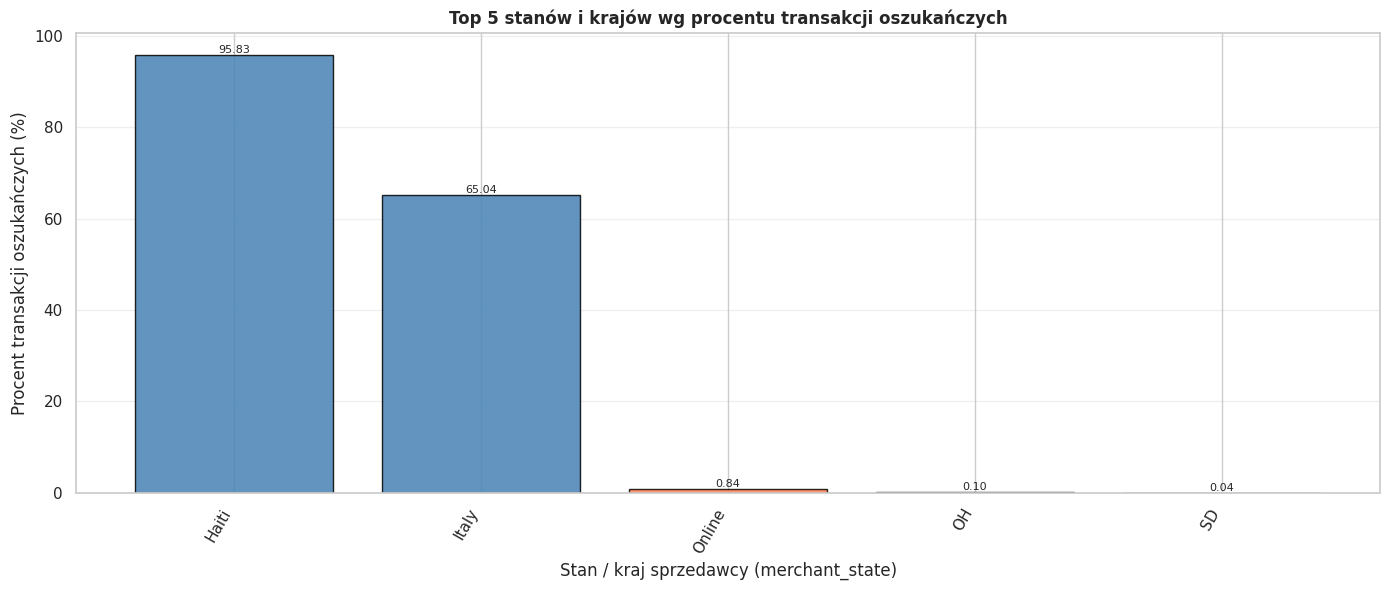

In [20]:
analysis.plot_graph(
    plot_state_fraud_rate,
    load_all_transactions(),
    top_n=5,
    min_transactions=100,
)

## Profilowanie klientów oszukańczych

Klient traktowany jest jako **oszust**, gdy ma **więcej niż 1** potwierdzoną transakcję oszukańczą (`fraud_count > 1`) — przy progu 1 niemal każdy klient byłby oszustem. Etykieta `fraud` jest nullable (~1/3 braków); braki liczone są jako brak oszustwa, więc `fraud_count` nigdy nie zawyża. Porównania używają średnich / gęstości (a nie liczb bezwzględnych), bo grupy są mocno niezbalansowane (~1112 vs ~107).

In [18]:
profile = build_client_fraud_profile(analysis.transactions, analysis.users, analysis.cards, min_fraud_txns=22)
print(f"Oszuści (>1 transakcja): {int(profile['is_fraudster'].sum()):,} / {len(profile):,} klientów")
profile.loc[profile["is_fraudster"], "fraud_count"].describe()

Oszuści (>1 transakcja): 144 / 1,219 klientów


count    144.000000
mean      28.645833
std        6.637959
min       22.000000
25%       24.000000
50%       26.000000
75%       32.000000
max       58.000000
Name: fraud_count, dtype: float64

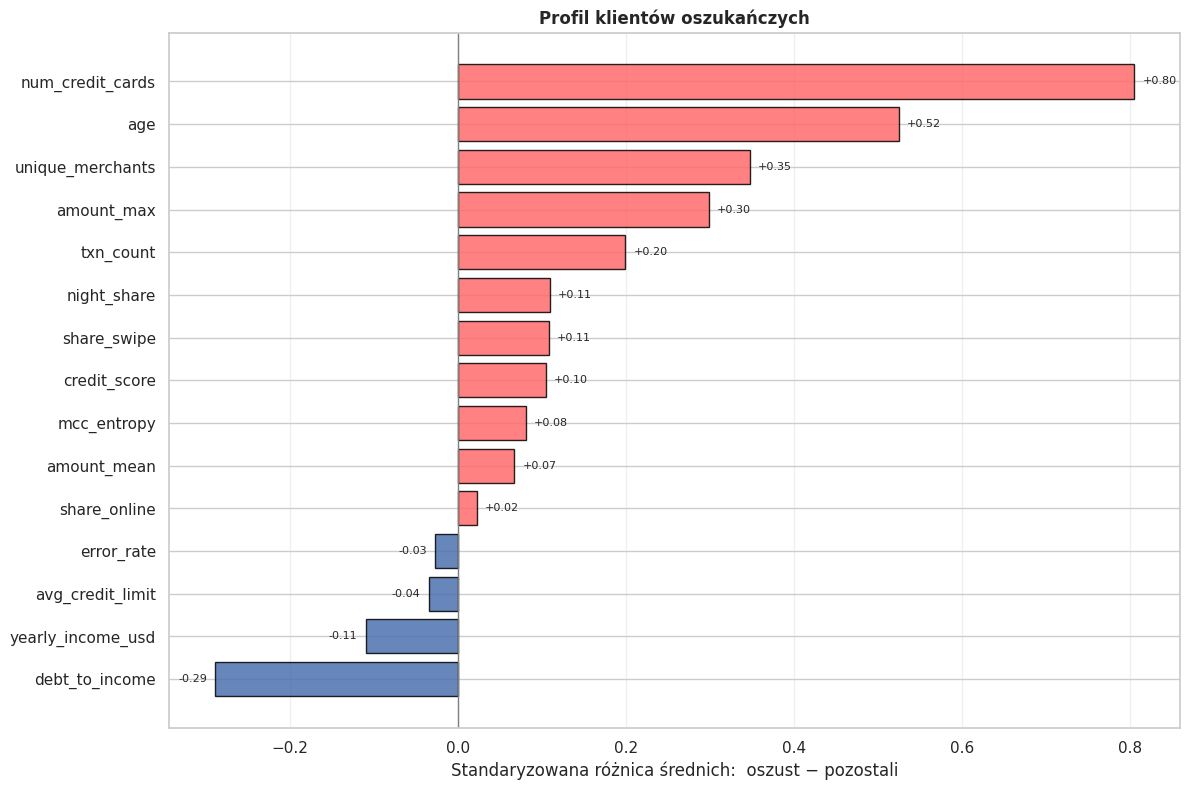

In [19]:
analysis.plot_graph(plot_fraudster_profile, profile)

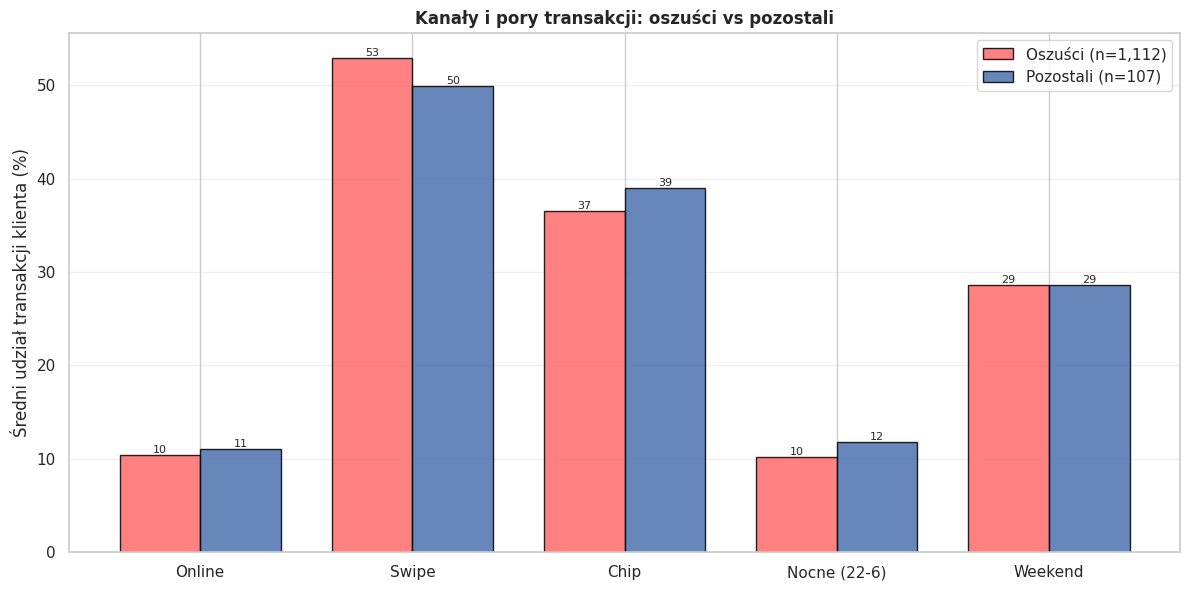

In [14]:
analysis.plot_graph(plot_fraudster_channel_mix, profile)

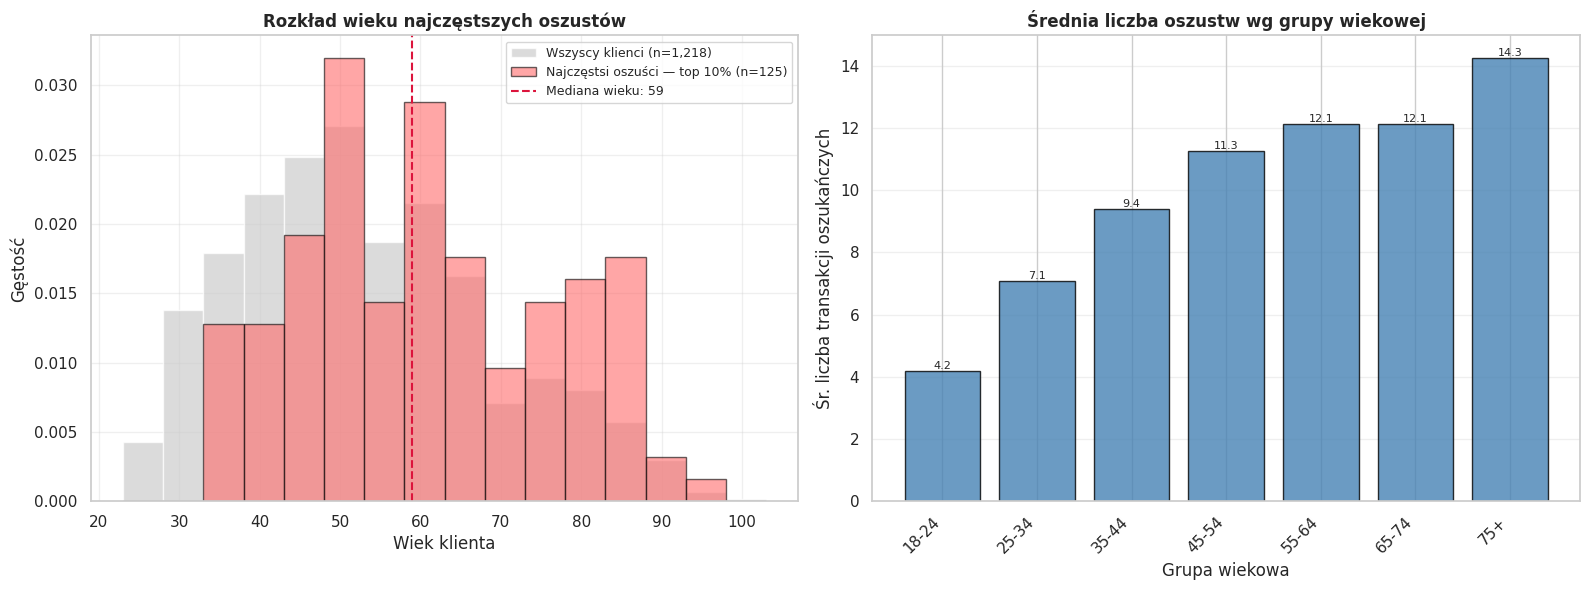

In [15]:
analysis.plot_graph(plot_fraud_frequent_age, profile, top_frac=0.1)

## Profilowanie sprzedawców oszukańczych

Wskaźniki oszustw liczone tylko na transakcjach z etykietą (`fraud.notna()`). Filtr `min_transactions` zapobiega temu, by pojedyncze oszustwo u małego sprzedawcy wskoczyło na 100%.

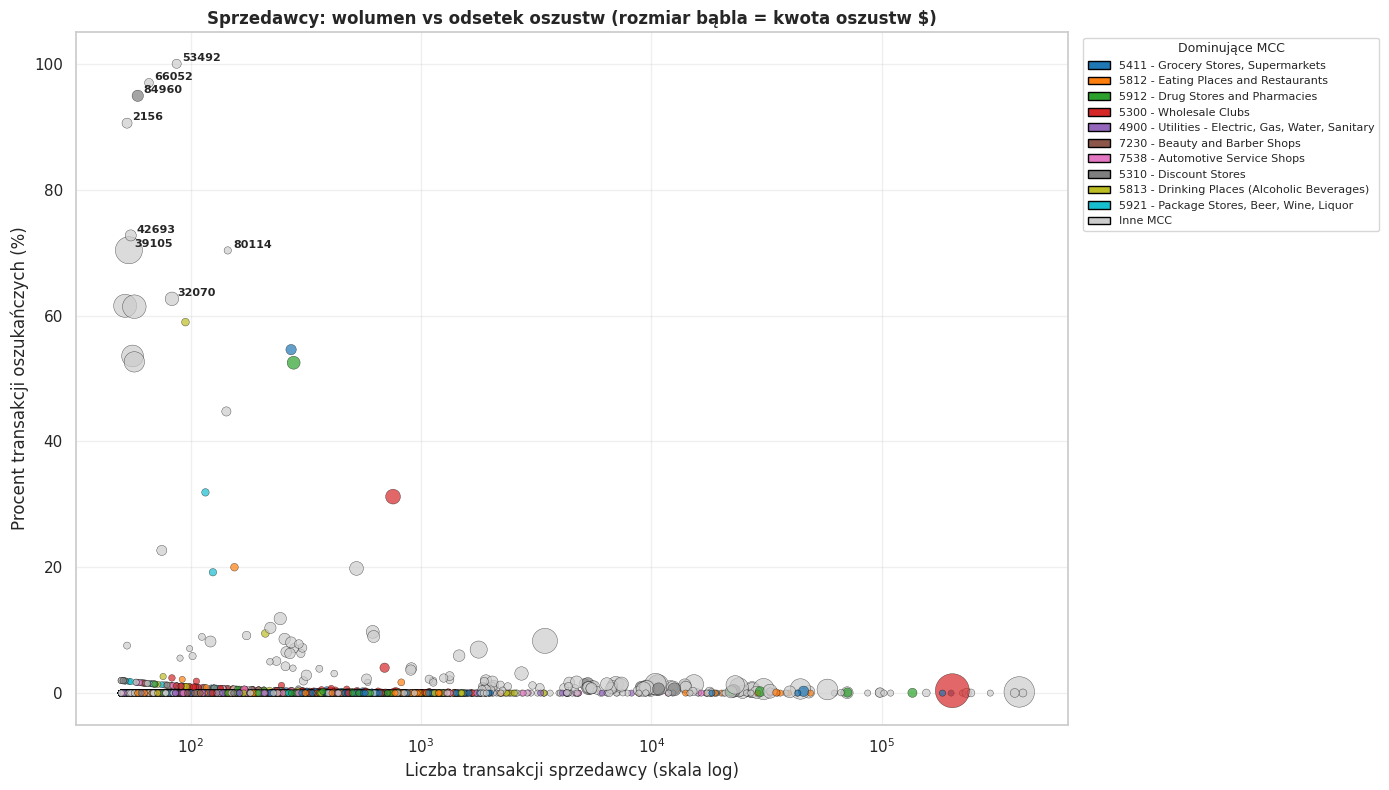

In [16]:
analysis.plot_graph(
    plot_merchant_fraud_rate_volume,
    load_all_transactions(),
    mcc_codes=load_mcc_codes(),
    min_transactions=50,
)

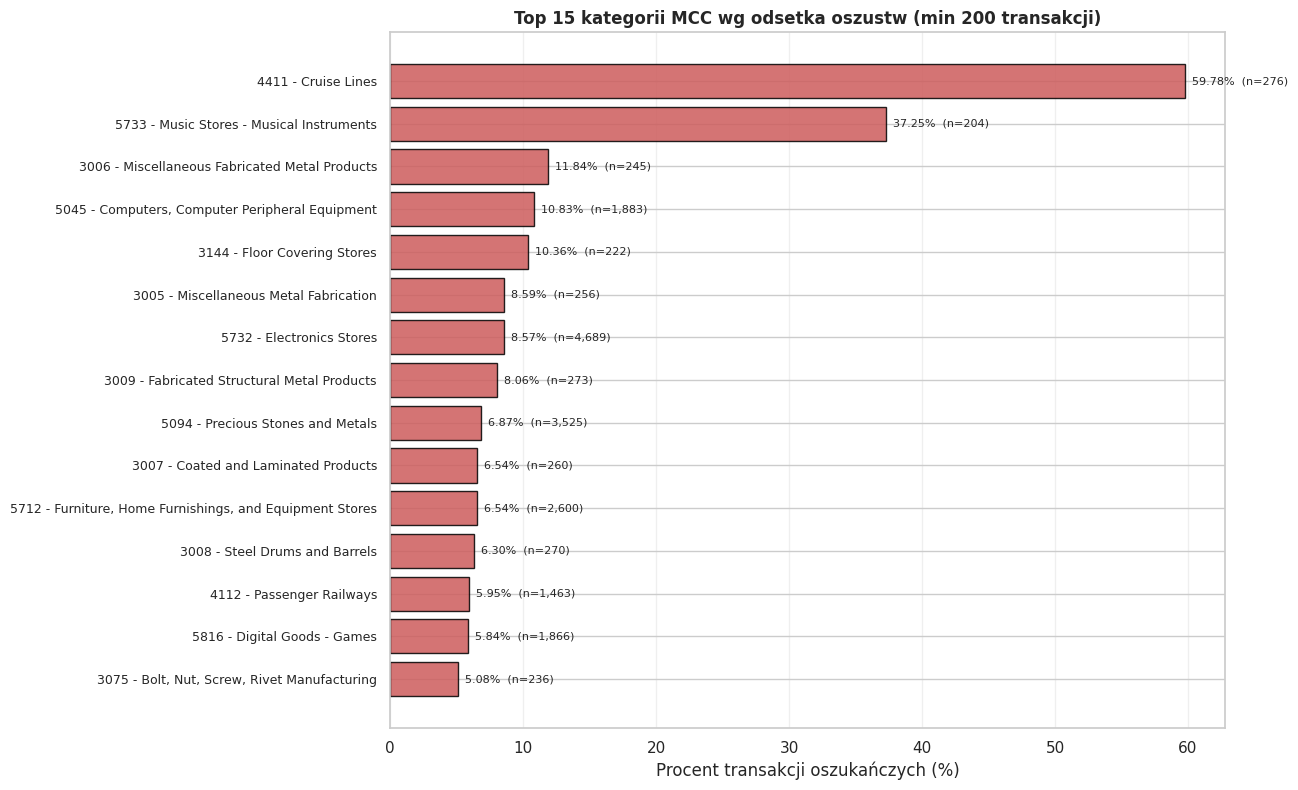

In [ ]:
analysis.plot_graph(
    plot_mcc_fraud_rate,
    load_all_transactions(),
    mcc_codes=load_mcc_codes(),
    top_n=15,
    min_transactions=200,
)

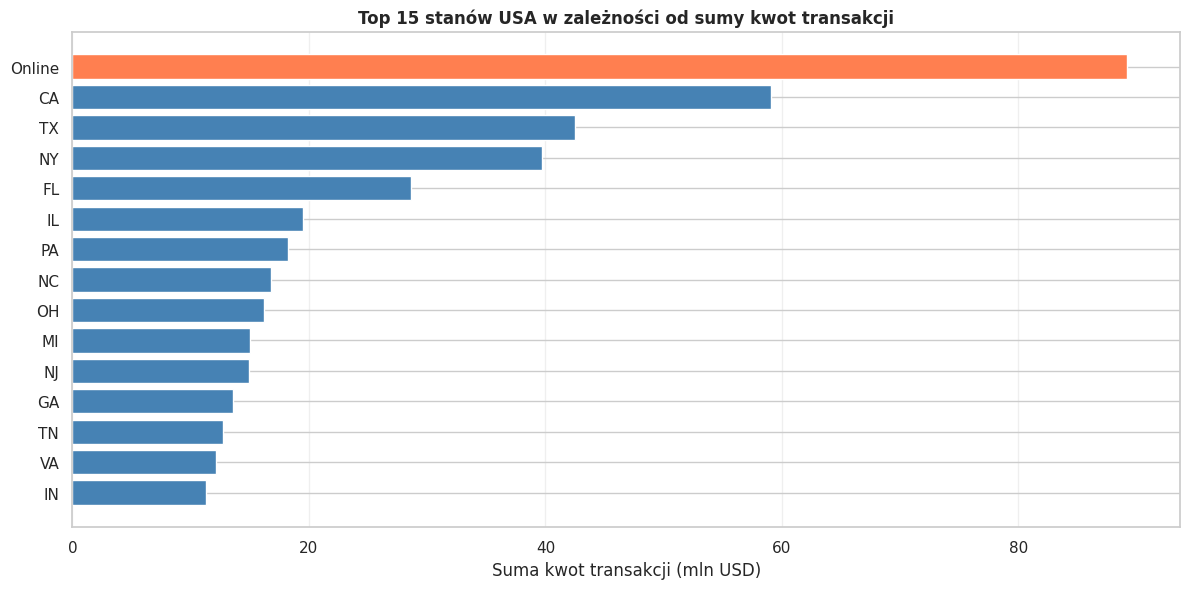

In [3]:
analysis.plot_graph(plot_top_states_by_amount, analysis.transactions, top_n=15)